<a href="https://colab.research.google.com/github/Dentriciche/Project_SP/blob/main/baseline_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Logistic Regression Model for South Park Character Classification

This notebook implements a baseline multiclass classification model to predict which South Park character spoke a given line of dialogue.

## Objectives:
- Load and preprocess the South Park dialogue dataset
- Build a parameterized logistic regression model (single-layer neural network)
- Train the model with proper handling of class imbalance
- Evaluate performance using comprehensive metrics

## Model Architecture:
The model is designed to be easily extensible to deeper networks by adding hidden layers.

## 1. Imports and Setup

In [203]:
!pip install gensim

In [204]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from collections import Counter
from typing import List, Dict, Tuple

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# Add to existing imports
import gensim.downloader as api
import numpy as np
# Import evaluation utilities
from evaluate_models import (
    evaluate_model,
    print_evaluation_report,
    plot_confusion_matrix,
    get_per_class_metrics,
    print_classification_report,
    compare_models
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Configuration Parameters

These parameters control the dataset size and model behavior:

In [205]:
# Dataset configuration
K = 30  # Number of top characters to include

# FastText configuration
USE_FASTTEXT = False  # Set to False to use random embeddings
FREEZE_EMBEDDINGS = False  # Set to True to prevent fine-tuning FastText embeddings

# Model hyperparameters
if USE_FASTTEXT:
    EMBEDDING_DIM = 300  # FastText uses 300-dimensional vectors
else:
    EMBEDDING_DIM = 64  # Original random embedding dimension

NUM_HIDDEN_LAYERS = 0  # 0 for logistic regression
HIDDEN_DIM = 128
DROPOUT_RATE = 0.5

# Training hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 25

# Data split
VAL_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Configuration:")
print(f"  Top K characters: {K}")
print(f"  Using FastText: {USE_FASTTEXT}")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Freeze embeddings: {FREEZE_EMBEDDINGS}")
print(f"  Hidden layers: {NUM_HIDDEN_LAYERS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Configuration:
  Top K characters: 30
  Using FastText: False
  Embedding dimension: 64
  Freeze embeddings: False
  Hidden layers: 0
  Batch size: 64
  Learning rate: 0.001
  Epochs: 25


## 3. Data Loading

Load the South Park dialogue dataset from GitHub (seasons 1-19):

In [206]:
# Load data from GitHub
base_url = "https://raw.githubusercontent.com/BobAdamsEE/SouthParkData/refs/heads/master/by-season/Season-{}.csv"

print("Loading South Park dialogue data...")
dfs = []
for season in tqdm(range(1, 20), desc="Loading seasons"):
    url = base_url.format(season)
    dfs.append(pd.read_csv(url))

df = pd.concat(dfs, ignore_index=True)
print(f"\nLoaded {len(df):,} dialogue lines")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loading South Park dialogue data...


Loading seasons: 100%|██████████| 19/19 [00:04<00:00,  4.33it/s]



Loaded 73,139 dialogue lines
Columns: ['Season', 'Episode', 'Character', 'Line']


,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru...\n"
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.\n
3,1,1,Kyle,"Ike, you can't come to school with me. \n"
4,1,1,Cartman,"Yeah, go home you little dildo.\n"


## 4. Data Cleaning and Character Selection

In [207]:
# Remove duplicates
df_clean = df.drop_duplicates()
print(f"After removing duplicates: {len(df_clean):,} lines")


# Strip whitespace from character names
df_clean['Character'] = df_clean['Character'].str.strip()
df_clean['Line'] = df_clean['Line'].str.strip()

# Remove empty lines
df_clean = df_clean[df_clean['Line'].str.len() > 0]
print(f"After removing empty lines: {len(df_clean):,} lines")

After removing duplicates: 72,238 lines
After removing empty lines: 72,238 lines


/tmp/ipython-input-3841781817.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Character'] = df_clean['Character'].str.strip()
/tmp/ipython-input-3841781817.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Line'] = df_clean['Line'].str.strip()


In [208]:
# Select top K characters by number of lines
character_counts = df_clean['Character'].value_counts()
top_k_characters = character_counts.head(K).index.tolist()

print(f"\nTop {K} characters:")
for i, char in enumerate(top_k_characters, 1):
    count = character_counts[char]
    print(f"  {i:2d}. {char:20s} - {count:5d} lines ({count/len(df_clean)*100:.1f}%)")

# Filter dataset to only include top K characters
df_model = df_clean[df_clean['Character'].isin(top_k_characters)].copy()
print(f"\nFiltered dataset: {len(df_model):,} lines ({len(df_model)/len(df_clean)*100:.1f}% of total)")


Top 30 characters:
   1. Cartman              -  9911 lines (13.7%)
   2. Stan                 -  7681 lines (10.6%)
   3. Kyle                 -  7141 lines (9.9%)
   4. Butters              -  2695 lines (3.7%)
   5. Randy                -  2656 lines (3.7%)
   6. Mr. Garrison         -  1082 lines (1.5%)
   7. Chef                 -   911 lines (1.3%)
   8. Sharon               -   888 lines (1.2%)
   9. Kenny                -   878 lines (1.2%)
  10. Jimmy                -   680 lines (0.9%)
  11. Mr. Mackey           -   650 lines (0.9%)
  12. Gerald               -   646 lines (0.9%)
  13. Liane                -   596 lines (0.8%)
  14. Wendy                -   584 lines (0.8%)
  15. Jimbo                -   560 lines (0.8%)
  16. Sheila               -   559 lines (0.8%)
  17. Announcer            -   410 lines (0.6%)
  18. Stephen              -   376 lines (0.5%)
  19. Craig                -   358 lines (0.5%)
  20. Clyde                -   315 lines (0.4%)
  21. Jesus       

## 5. Create Character-to-Label Mapping

In [209]:
# Create character to label mapping
char_to_label = {char: idx for idx, char in enumerate(top_k_characters)}
label_to_char = {idx: char for char, idx in char_to_label.items()}

# Add label column
df_model['label'] = df_model['Character'].map(char_to_label)

print("Character to Label Mapping:")
for char, label in char_to_label.items():
    print(f"  {label:2d}: {char}")

# Extract texts and labels
texts = df_model['Line'].tolist()
labels = df_model['label'].tolist()

print(f"\nTotal samples: {len(texts):,}")
print(f"Number of classes: {len(char_to_label)}")

Character to Label Mapping:
   0: Cartman
   1: Stan
   2: Kyle
   3: Butters
   4: Randy
   5: Mr. Garrison
   6: Chef
   7: Sharon
   8: Kenny
   9: Jimmy
  10: Mr. Mackey
  11: Gerald
  12: Liane
  13: Wendy
  14: Jimbo
  15: Sheila
  16: Announcer
  17: Stephen
  18: Craig
  19: Clyde
  20: Jesus
  21: Principal Victoria
  22: Linda
  23: Token
  24: Mrs. Garrison
  25: Terrance
  26: Tweek
  27: Mayor
  28: Phillip
  29: Bebe

Total samples: 42,276
Number of classes: 30


## 6. Visualize Class Distribution

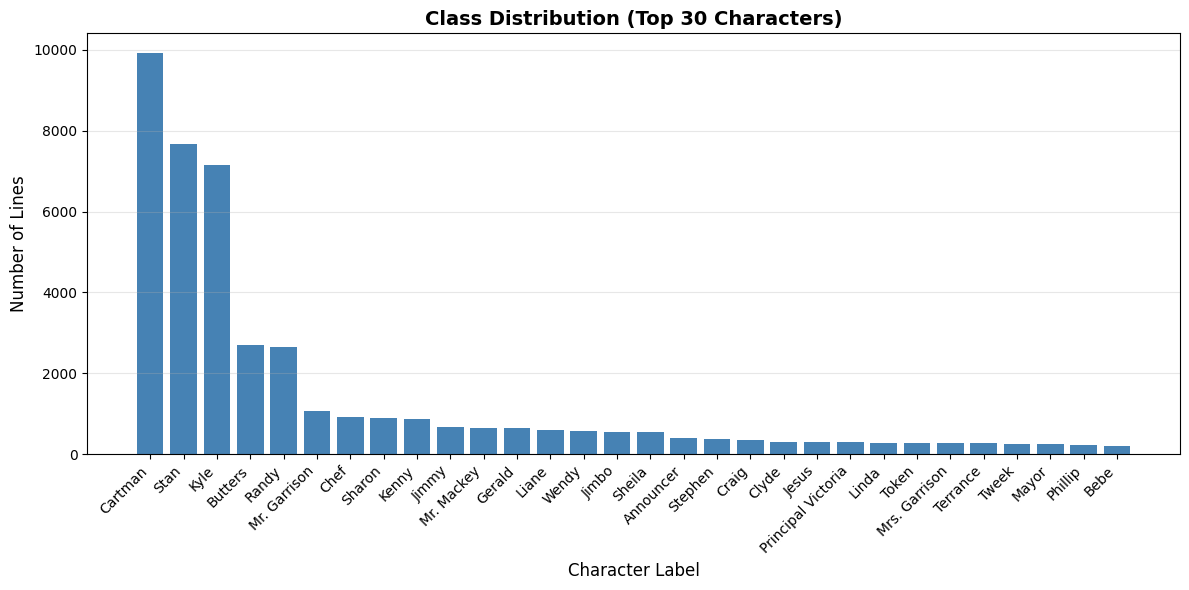


Class Distribution Statistics:
  Min samples: 216
  Max samples: 9,911
  Mean samples: 1409
  Imbalance ratio: 45.88:1


In [210]:
# Plot class distribution
plt.figure(figsize=(12, 6))
label_counts = pd.Series(labels).value_counts().sort_index()
plt.bar(range(len(label_counts)), label_counts.values, color='steelblue')
plt.xlabel('Character Label', fontsize=12)
plt.ylabel('Number of Lines', fontsize=12)
plt.title(f'Class Distribution (Top {K} Characters)', fontsize=14, fontweight='bold')
plt.xticks(range(len(label_counts)), [label_to_char[i] for i in range(len(label_counts))], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print class imbalance statistics
print("\nClass Distribution Statistics:")
print(f"  Min samples: {label_counts.min():,}")
print(f"  Max samples: {label_counts.max():,}")
print(f"  Mean samples: {label_counts.mean():.0f}")
print(f"  Imbalance ratio: {label_counts.max() / label_counts.min():.2f}:1")

## 7. Train/Validation/Test Split

Split data while maintaining class distribution (stratified split):

In [211]:
# First split: separate test set
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    texts, labels,
    test_size=TEST_SIZE,
    stratify=labels,
    random_state=42
)

# Second split: separate validation set from training
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)  # Adjust validation size
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=val_size_adjusted,
    stratify=train_val_labels,
    random_state=42
)

print("Data Split:")
print(f"  Training samples:   {len(train_texts):,} ({len(train_texts)/len(texts)*100:.1f}%)")
print(f"  Validation samples: {len(val_texts):,} ({len(val_texts)/len(texts)*100:.1f}%)")
print(f"  Test samples:       {len(test_texts):,} ({len(test_texts)/len(texts)*100:.1f}%)")

Data Split:
  Training samples:   29,592 (70.0%)
  Validation samples: 6,342 (15.0%)
  Test samples:       6,342 (15.0%)


## 8. Text Preprocessing and Vocabulary Building

**Important**: Build vocabulary only from training data to prevent data leakage!

In [212]:
def preprocess_text(text: str) -> List[str]:
    """
    Clean and tokenize text.

    Args:
        text: Raw text string

    Returns:
        List of tokens (words)
    """
    # Convert to lowercase
    text = text.lower()
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Split into words
    words = text.split()
    return words

# Preprocess all texts
print("Preprocessing texts...")
processed_train_texts = [preprocess_text(text) for text in tqdm(train_texts, desc="Train")]
processed_val_texts = [preprocess_text(text) for text in tqdm(val_texts, desc="Val")]
processed_test_texts = [preprocess_text(text) for text in tqdm(test_texts, desc="Test")]

Preprocessing texts...


Test: 100%|██████████| 6342/6342 [00:00<00:00, 40549.45it/s]


In [213]:
class Vocabulary:
    """
    Vocabulary class for managing word-to-index mappings.
    """
    def __init__(self, min_freq: int = 1, max_size: int = None):
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.min_freq = min_freq
        self.max_size = max_size

    def build_vocab(self, texts: List[List[str]]):
        """Build vocabulary from tokenized texts."""
        # Count word frequencies
        word_counts = Counter(word for text in texts for word in text)

        # Filter by minimum frequency
        word_counts = {word: count for word, count in word_counts.items()
                      if count >= self.min_freq}

        # Sort by frequency (most common first)
        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

        # Apply max vocabulary size if specified
        if self.max_size:
            sorted_words = sorted_words[:self.max_size - 2]  # -2 for <pad> and <unk>

        # Build mappings
        for word, _ in sorted_words:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, text: List[str]) -> List[int]:
        """Convert tokens to indices."""
        return [self.word2idx.get(word, self.word2idx['<unk>']) for word in text]

    def __len__(self):
        return len(self.word2idx)

# Build vocabulary from training data only
vocab = Vocabulary(min_freq=2)
vocab.build_vocab(processed_train_texts)

print(f"\nVocabulary size: {len(vocab):,} words")
print(f"  (including <pad> and <unk> tokens)")


Vocabulary size: 8,077 words
  (including <pad> and <unk> tokens)


In [214]:
# ========================================
# NEW SECTION: Load FastText Embeddings
# ========================================

pretrained_embeddings = None

if USE_FASTTEXT:
    print("="*60)
    print("LOADING FASTTEXT PRE-TRAINED EMBEDDINGS")
    print("="*60)

    # Load pre-trained FastText model (downloads ~1GB on first run)
    print("\nDownloading/Loading FastText model...")
    print("This may take a few minutes on first run...")
    fasttext_model = api.load('fasttext-wiki-news-subwords-300')
    print(" FastText model loaded!")

    # Create embedding matrix for your vocabulary
    vocab_size = len(vocab)
    embedding_dim = 300  # FastText dimension

    print(f"\nCreating embedding matrix...")
    print(f"  Vocabulary size: {vocab_size:,}")
    print(f"  Embedding dimension: {embedding_dim}")

    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    found_words = 0
    oov_words = []

    # Map each word in your vocabulary to FastText embedding
    for word, idx in vocab.word2idx.items():
        try:
            if word in fasttext_model:
                embedding_matrix[idx] = fasttext_model[word]
                found_words += 1
            else:
                # Random initialization for OOV words
                embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
                if word not in ['<pad>', '<unk>']:
                    oov_words.append(word)
        except KeyError:
            # Fallback for any errors
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            if word not in ['<pad>', '<unk>']:
                oov_words.append(word)

    # Statistics
    print(f"\n{'='*60}")
    print("EMBEDDING MATRIX STATISTICS")
    print(f"{'='*60}")
    print(f"Total vocabulary: {vocab_size:,}")
    print(f"Found in FastText: {found_words:,} ({found_words/vocab_size*100:.1f}%)")
    print(f"Out-of-vocabulary: {len(oov_words):,} ({len(oov_words)/vocab_size*100:.1f}%)")

    if len(oov_words) <= 30:
        print(f"\nOOV words (not in FastText):")
        print(f"  {oov_words}")
    else:
        print(f"\nFirst 30 OOV words:")
        print(f"  {oov_words[:30]}")

    # Convert to PyTorch tensor
    pretrained_embeddings = torch.FloatTensor(embedding_matrix)
    print(f"\n Pre-trained embeddings ready: {pretrained_embeddings.shape}")
    print(f"{'='*60}\n")

else:
    print("Using random embeddings (no FastText)")
    pretrained_embeddings = None

Using random embeddings (no FastText)


In [215]:
# Encode texts to indices
print("\nEncoding texts to indices...")
indexed_train_texts = [vocab.encode(text) for text in processed_train_texts]
indexed_val_texts = [vocab.encode(text) for text in processed_val_texts]
indexed_test_texts = [vocab.encode(text) for text in processed_test_texts]

# Show example
print("\nExample encoding:")
print(f"  Original: {train_texts[0][:100]}...")
print(f"  Tokens:   {processed_train_texts[0][:10]}")
print(f"  Indices:  {indexed_train_texts[0][:10]}")


Encoding texts to indices...

Example encoding:
  Original: Uhh... no....
  Tokens:   ['uhh', 'no']
  Indices:  [594, 27]


## 9. PyTorch Dataset and DataLoader

In [216]:
class DialogueDataset(Dataset):
    """
    PyTorch Dataset for South Park dialogue classification.
    """
    def __init__(self, texts: List[List[int]], labels: List[int]):
        self.texts = texts
        self.labels = labels
        self.classes = sorted(list(set(labels)))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            'text': torch.tensor(self.texts[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = DialogueDataset(indexed_train_texts, train_labels)
val_dataset = DialogueDataset(indexed_val_texts, val_labels)
test_dataset = DialogueDataset(indexed_test_texts, test_labels)

print(f"Created datasets:")
print(f"  Train: {len(train_dataset):,} samples")
print(f"  Val:   {len(val_dataset):,} samples")
print(f"  Test:  {len(test_dataset):,} samples")

Created datasets:
  Train: 29,592 samples
  Val:   6,342 samples
  Test:  6,342 samples


In [217]:
def collate_batch(batch):
    """
    Collate function to handle variable-length sequences.
    Pads sequences to the maximum length in the batch.
    """
    labels = torch.tensor([item['label'] for item in batch])
    texts = [item['text'] for item in batch]

    # Find max length in this batch
    max_len = max(len(text) for text in texts)

    # Pad sequences
    padded_texts = torch.zeros(len(texts), max_len, dtype=torch.long)
    for i, text in enumerate(texts):
        padded_texts[i, :len(text)] = text

    return padded_texts.to(device), labels.to(device)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

print(f"\nCreated DataLoaders with batch size {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


Created DataLoaders with batch size 64
  Train batches: 463
  Val batches:   100
  Test batches:  100


## 10. Model Architecture

### Embedding Strategy Discussion

For this character classification task, we have several embedding options:

1. **`nn.Embedding` (Trainable)**
   - Learns task-specific word representations
   - Best for capturing character-specific vocabulary and speaking patterns
   - Works well even with moderate dataset sizes
   - Simple to implement and train end-to-end

2. **Pre-trained Embeddings (GloVe/Word2Vec)**
   - Pros: Leverage general language knowledge
   - Cons: May not capture South Park-specific slang, character names, or humor
   - Use case: When training data is very limited (<1000 samples per class)

3. **Character-level Embeddings**
   - Pros: Can handle misspellings and character names better
   - Cons: More complex, requires more computation
   - Use case: When dealing with lots of out-of-vocabulary words

**For this baseline, we use trainable `nn.Embedding`** as it provides the best balance of simplicity and performance.

In [218]:
class CharacterClassifier(nn.Module):
    """
    Parameterized neural network for character classification.

    Can function as:
    - Logistic regression (num_hidden_layers=0)
    - Deep neural network (num_hidden_layers>0)

    Args:
        vocab_size: Size of vocabulary
        embedding_dim: Dimension of word embeddings
        num_classes: Number of output classes (characters)
        num_hidden_layers: Number of hidden layers (0 for logistic regression)
        hidden_dim: Dimension of hidden layers
        dropout_rate: Dropout rate for regularization
        pretrained_embeddings: Optional pre-trained embeddings (e.g., FastText)
        freeze_embeddings: Whether to freeze embedding weights
    """
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_classes: int,
        num_hidden_layers: int = 0,
        hidden_dim: int = 128,
        dropout_rate: float = 0.5,
        pretrained_embeddings: torch.Tensor = None,  # ← NEW
        freeze_embeddings: bool = False  # ← NEW
    ):
        super().__init__()

        # Embedding layer
        if pretrained_embeddings is not None:
            # Use pre-trained embeddings (e.g., FastText)
            print(f"Using pre-trained embeddings: {pretrained_embeddings.shape}")
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings,
                freeze=freeze_embeddings,
                padding_idx=0
            )
            if freeze_embeddings:
                print("  Embeddings are FROZEN (not trainable)")
            else:
                print("  Embeddings are TRAINABLE (will be fine-tuned)")
        else:
            # Random initialization (original approach)
            print(f"Using random embeddings: {vocab_size} x {embedding_dim}")
            self.embedding = nn.Embedding(
                vocab_size,
                embedding_dim,
                padding_idx=0
            )
            self.embedding_bag = None

            # self.embedding_bag = nn.EmbeddingBag(vocab_size, embedding_dim, mode='mean')

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Build hidden layers
        self.hidden_layers = nn.ModuleList()

        if num_hidden_layers == 0:
            # Logistic regression: direct embedding -> output
            self.fc_out = nn.Linear(embedding_dim, num_classes)
        else:
            # Deep network: embedding -> hidden layers -> output
            # First hidden layer
            self.hidden_layers.append(nn.Linear(embedding_dim, hidden_dim))

            # Additional hidden layers
            for _ in range(num_hidden_layers - 1):
                self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))

            # Output layer
            self.fc_out = nn.Linear(hidden_dim, num_classes)

        self.num_hidden_layers = num_hidden_layers

    def forward(self, text):
        """
        Forward pass.

        Args:
            text: Tensor of shape (batch_size, seq_len)

        Returns:
            Logits of shape (batch_size, num_classes)
        """
        # Embed tokens: (batch_size, seq_len, embedding_dim)
        if pretrained_embeddings is not None or self.embedding_bag is None:
          embedded = self.embedding(text)

          # Create mask for padding tokens
          mask = (text != 0).float().unsqueeze(-1)  # (batch_size, seq_len, 1)

          # Apply mask to embeddings
          embedded = embedded * mask

          # Mean pooling: average over sequence length
          pooled = embedded.sum(dim=1) / mask.sum(dim=1).clamp(min=1)

          # Apply dropout
          pooled = self.dropout(pooled)
        else:
          embedded = self.embedding_bag(text)
          pooled = embedded

        # Pass through hidden layers (if any)
        x = pooled
        for hidden_layer in self.hidden_layers:
            x = hidden_layer(x)
            x = torch.relu(x)
            x = self.dropout(x)

        # Output layer
        logits = self.fc_out(x)

        return logits

## 11. Initialize Model

In [219]:
# Initialize model
# Initialize model
print("Initializing model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if USE_FASTTEXT:
    print(f"  Using pre-trained FastText embeddings")
    model = CharacterClassifier(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_classes=K,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        dropout_rate=DROPOUT_RATE,
        pretrained_embeddings=pretrained_embeddings,
        freeze_embeddings=FREEZE_EMBEDDINGS
    ).to(device)
    embedding_params = sum(p.numel() for p in model.embedding.parameters())
else:
    model = CharacterClassifier(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_classes=K,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        dropout_rate=DROPOUT_RATE
    ).to(device)
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

if FREEZE_EMBEDDINGS:
    print(f"  Non-embedding trainable: {trainable_params - embedding_params:,}")
    print(f"  Embedding parameters: {embedding_params:,}")

print(f"\nModel architecture:")
print(model)

Initializing model...
Using random embeddings: 8077 x 64

Model Statistics:
  Total parameters: 518,878
  Trainable parameters: 518,878

Model architecture:
CharacterClassifier(
  (embedding): Embedding(8077, 64, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (hidden_layers): ModuleList()
  (fc_out): Linear(in_features=64, out_features=30, bias=True)
)


## 12. Handle Class Imbalance with Class Weights

Calculate class weights to handle imbalanced dataset:

In [220]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights (to handle imbalance):")
for i, weight in enumerate(class_weights):
    char_name = label_to_char[i]
    print(f"  {i:2d}. {char_name:20s} - weight: {weight:.3f}")

Class Weights (to handle imbalance):
   0. Cartman              - weight: 0.142
   1. Stan                 - weight: 0.183
   2. Kyle                 - weight: 0.197
   3. Butters              - weight: 0.523
   4. Randy                - weight: 0.531
   5. Mr. Garrison         - weight: 1.301
   6. Chef                 - weight: 1.549
   7. Sharon               - weight: 1.586
   8. Kenny                - weight: 1.607
   9. Jimmy                - weight: 2.072
  10. Mr. Mackey           - weight: 2.168
  11. Gerald               - weight: 2.182
  12. Liane                - weight: 2.365
  13. Wendy                - weight: 2.418
  14. Jimbo                - weight: 2.516
  15. Sheila               - weight: 2.523
  16. Announcer            - weight: 3.437
  17. Stephen              - weight: 3.751
  18. Craig                - weight: 3.946
  19. Clyde                - weight: 4.463
  20. Jesus                - weight: 4.546
  21. Principal Victoria   - weight: 4.653
  22. Linda      

## 13. Training Setup

In [221]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(f"Training setup:")
print(f"  Loss function: CrossEntropyLoss (with class weights)")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Epochs: {NUM_EPOCHS}")

Training setup:
  Loss function: CrossEntropyLoss (with class weights)
  Optimizer: Adam (lr=0.001)
  Epochs: 25


## 14. Training Loop

In [222]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

print("\nStarting training...\n")
print("="*70)
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for text, labels in train_pbar:
        # Forward pass
        optimizer.zero_grad()
        outputs = model(text)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text, labels in val_loader:
            outputs = model(text)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    # Calculate metrics
    val_accuracy = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1'].append(val_f1)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_accuracy:.4f}")
    print(f"  Val F1:     {val_f1:.4f}")
    print("-"*70)

print("\nTraining complete!")
print("="*70)


Starting training...



Epoch 1/25 [Train]: 100%|██████████| 463/463 [00:09<00:00, 46.92it/s, loss=3.2089]


Epoch 1/25:
  Train Loss: 3.4272
  Val Loss:   3.3608
  Val Acc:    0.0727
  Val F1:     0.0439
----------------------------------------------------------------------


Epoch 2/25 [Train]: 100%|██████████| 463/463 [00:09<00:00, 48.78it/s, loss=3.3593]


Epoch 2/25:
  Train Loss: 3.3557
  Val Loss:   3.3233
  Val Acc:    0.0839
  Val F1:     0.0568
----------------------------------------------------------------------


...

Epoch 23/25:
  Train Loss: 2.7398
  Val Loss:   2.9607
  Val Acc:    0.1364
  Val F1:     0.1314
----------------------------------------------------------------------


Epoch 24/25 [Train]: 100%|██████████| 463/463 [00:05<00:00, 85.72it/s, loss=2.0550]


Epoch 24/25:
  Train Loss: 2.7309
  Val Loss:   2.9524
  Val Acc:    0.1377
  Val F1:     0.1341
----------------------------------------------------------------------


Epoch 25/25 [Train]: 100%|██████████| 463/463 [00:05<00:00, 79.85it/s, loss=2.8526]


Epoch 25/25:
  Train Loss: 2.7104
  Val Loss:   2.9432
  Val Acc:    0.1408
  Val F1:     0.1348
----------------------------------------------------------------------

Training complete!


## 15. Plot Training History

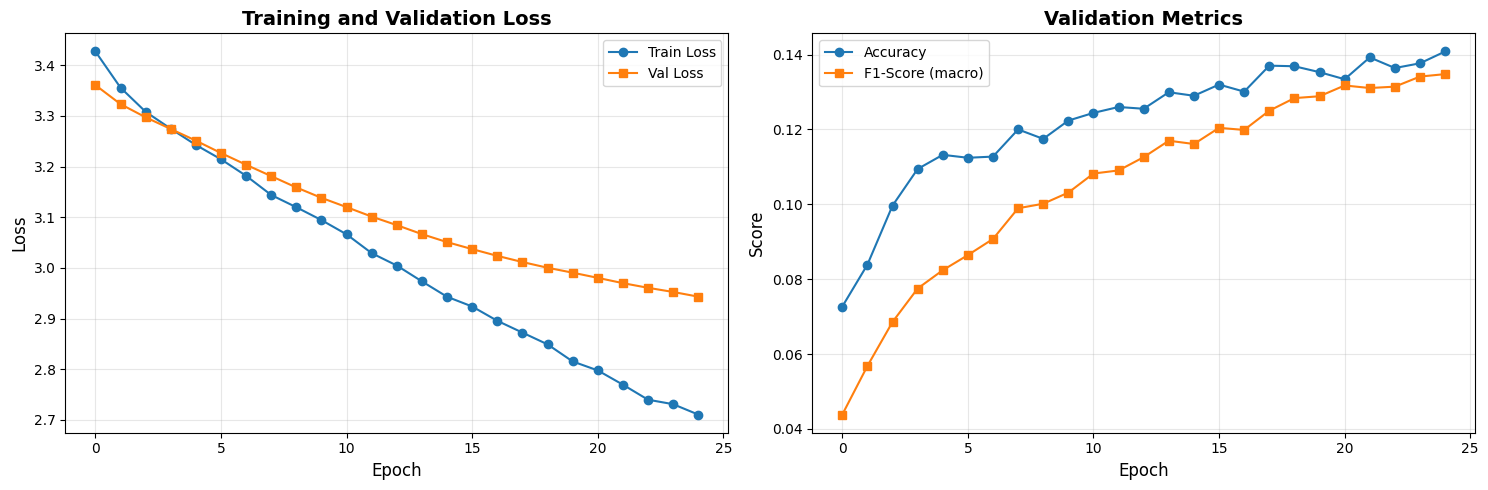

In [223]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot metrics
axes[1].plot(history['val_accuracy'], label='Accuracy', marker='o')
axes[1].plot(history['val_f1'], label='F1-Score (macro)', marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Validation Metrics', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Evaluate on Test Set

Use the evaluation utilities from `evaluate_models.py`:

In [224]:
# Evaluate on test set
test_metrics, test_preds, test_true = evaluate_model(
    model=model,
    data_loader=test_loader,
    device=device,
    class_names=top_k_characters,
    return_predictions=True
)

# Print evaluation report
print_evaluation_report(test_metrics, model_name="Baseline Logistic Regression")


Baseline Logistic Regression Evaluation Results
Accuracy:  0.1455
Precision: 0.1505 (macro)
Recall:    0.2341 (macro)
F1-Score:  0.1389 (macro)



## 17. Confusion Matrix

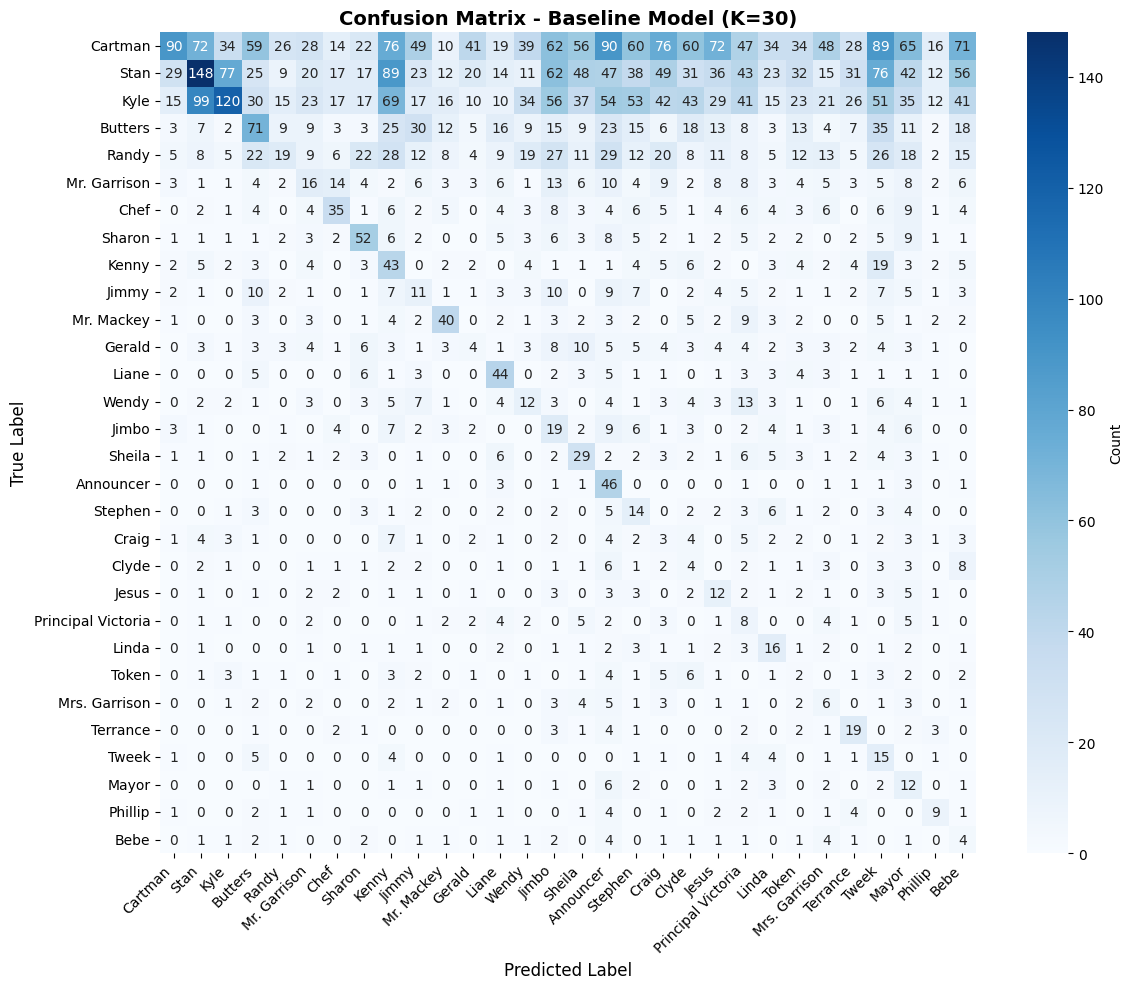

In [225]:
# Plot confusion matrix
plot_confusion_matrix(
    y_true=test_true,
    y_pred=test_preds,
    class_names=top_k_characters,
    title=f"Confusion Matrix - Baseline Model (K={K})",
    figsize=(12, 10)
)

## 18. Per-Class Performance

In [226]:
# Get per-class metrics
per_class_df = get_per_class_metrics(
    y_true=test_true,
    y_pred=test_preds,
    class_names=top_k_characters
)

print("\nPer-Class Performance:")
print("="*70)
print(per_class_df.to_string(index=False))
print("="*70)


Per-Class Performance:
             Class  Precision   Recall  F1-Score  Support
           Cartman   0.569620 0.060525  0.109422     1487
              Stan   0.408840 0.128472  0.195509     1152
              Kyle   0.466926 0.112045  0.180723     1071
           Butters   0.272031 0.175743  0.213534      404
             Randy   0.202128 0.047739  0.077236      398
      Mr. Garrison   0.115942 0.098765  0.106667      162
              Chef   0.289256 0.255474  0.271318      137
            Sharon   0.307692 0.390977  0.344371      133
             Kenny   0.109415 0.325758  0.163810      132
             Jimmy   0.060440 0.107843  0.077465      102
        Mr. Mackey   0.327869 0.408163  0.363636       98
            Gerald   0.040404 0.041237  0.040816       97
             Liane   0.273292 0.494382  0.352000       89
             Wendy   0.082192 0.136364  0.102564       88
             Jimbo   0.060127 0.226190  0.095000       84
            Sheila   0.123404 0.345238  0.181818

In [227]:
# Detailed classification report
print_classification_report(
    y_true=test_true,
    y_pred=test_preds,
    class_names=top_k_characters
)


Detailed Classification Report:
                    precision    recall  f1-score   support

           Cartman     0.5696    0.0605    0.1094      1487
              Stan     0.4088    0.1285    0.1955      1152
              Kyle     0.4669    0.1120    0.1807      1071
           Butters     0.2720    0.1757    0.2135       404
             Randy     0.2021    0.0477    0.0772       398
      Mr. Garrison     0.1159    0.0988    0.1067       162
              Chef     0.2893    0.2555    0.2713       137
            Sharon     0.3077    0.3910    0.3444       133
             Kenny     0.1094    0.3258    0.1638       132
             Jimmy     0.0604    0.1078    0.0775       102
        Mr. Mackey     0.3279    0.4082    0.3636        98
            Gerald     0.0404    0.0412    0.0408        97
             Liane     0.2733    0.4944    0.3520        89
             Wendy     0.0822    0.1364    0.1026        88
             Jimbo     0.0601    0.2262    0.0950        84
      

## 19. Save Model (Optional)

In [228]:
# Save model checkpoint
# Save model checkpoint
checkpoint = {
    'model_type': 'Logistic Regression' if NUM_HIDDEN_LAYERS == 0 else f'Deep Network ({NUM_HIDDEN_LAYERS} layers)',
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'K': K,
        'vocab_size': len(vocab),
        'embedding_dim': EMBEDDING_DIM,
        'num_hidden_layers': NUM_HIDDEN_LAYERS,
        'hidden_dim': HIDDEN_DIM,
        'dropout_rate': DROPOUT_RATE,
        'use_fasttext': USE_FASTTEXT,  # ← NEW
        'freeze_embeddings': FREEZE_EMBEDDINGS  # ← NEW
    },
    'char_to_label': char_to_label,
    'label_to_char': label_to_char,
    'vocab': vocab.word2idx,
    'test_metrics': test_metrics,
    'history': history,
    # 'training_time': elapsed
}

filename = f'baseline_logistic_k{K}_fasttext.pt' if USE_FASTTEXT else f'baseline_logistic_k{K}.pt'
torch.save(checkpoint, filename)
print(f"Model saved to: {filename}")

Model saved to: baseline_logistic_k30.pt


## 20. Next Steps and Experiments

### Suggested Experiments:

1. **Vary K (number of characters)**:
   - Try K=8, K=12, K=20 to see how performance changes
   - Smaller K = easier task, higher accuracy
   - Larger K = more challenging, more realistic

2. **Add hidden layers**:
   - Set `NUM_HIDDEN_LAYERS = 1` or `2`
   - Experiment with `HIDDEN_DIM` (64, 128, 256)
   - Compare deep network vs logistic regression

3. **Try different embeddings**:
   - Pre-trained GloVe embeddings
   - Different embedding dimensions (32, 64, 128, 256)
   - Character-level embeddings

4. **Hyperparameter tuning**:
   - Learning rate (0.0001, 0.001, 0.01)
   - Batch size (16, 32, 64)
   - Dropout rate (0.3, 0.5, 0.7)

5. **Advanced architectures**:
   - LSTM/GRU for sequence modeling
   - Attention mechanisms
   - Transformer-based models

### Model Comparison:
Use `compare_models()` from `evaluate_models.py` to compare different configurations!

Using random embeddings: 8077 x 64
Using random embeddings: 8230 x 300

Model Comparison:
                           accuracy  precision    recall  f1_score
LR with nn.Embedding 30 K  0.145538   0.150546  0.234102  0.138878
LR gensim embeddings 36 K  0.053295   0.041502  0.048289  0.026827


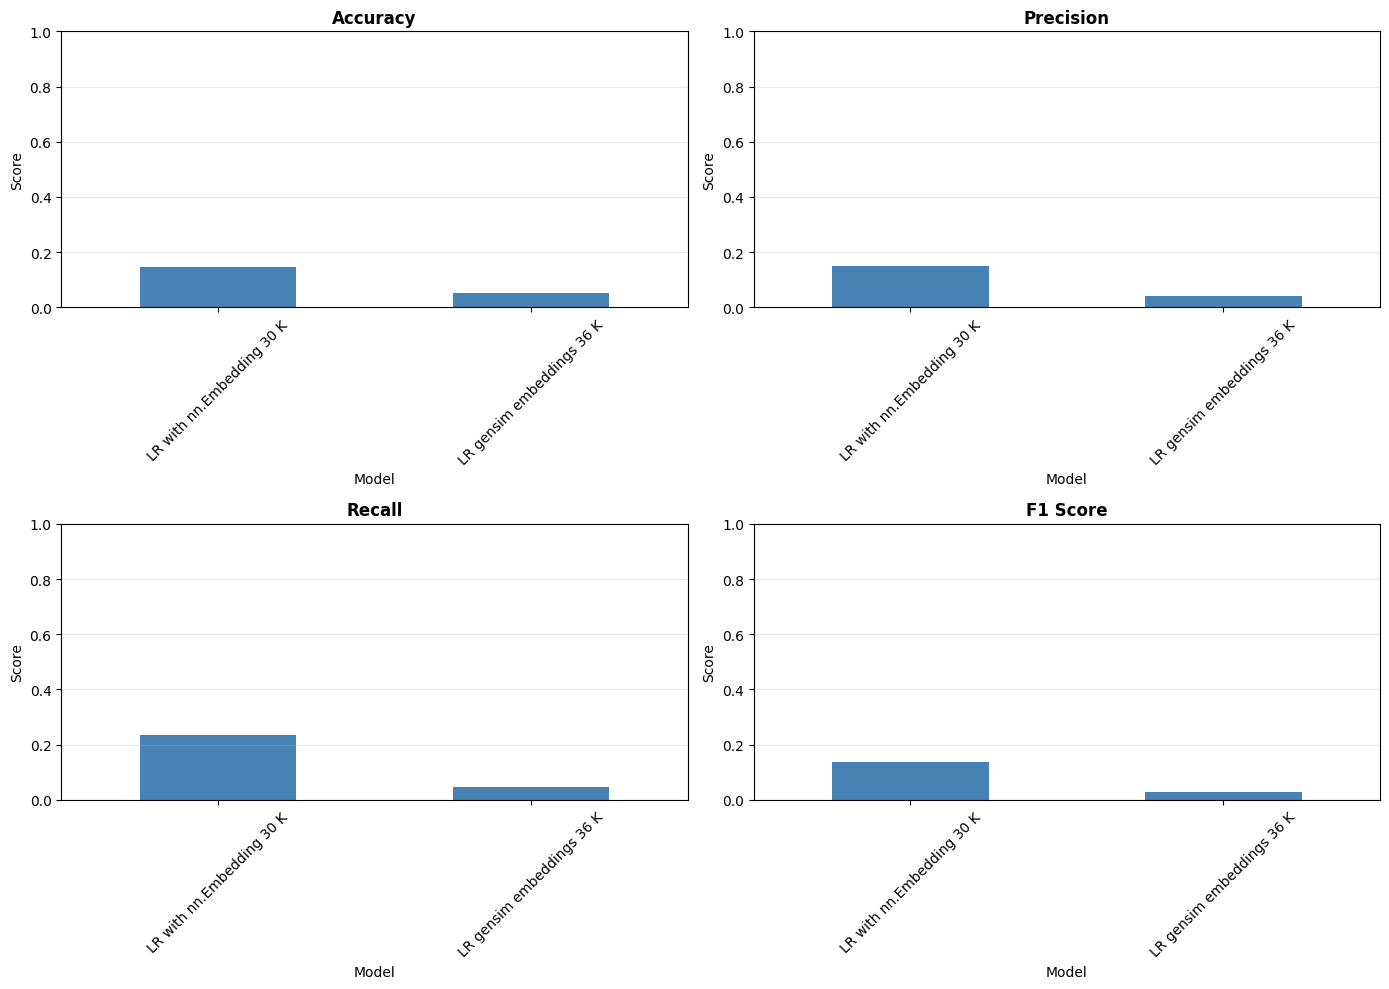

,accuracy,precision,recall,f1_score
LR with nn.Embedding 30 K,0.145538,0.150546,0.234102,0.138878
LR gensim embeddings 36 K,0.053295,0.041502,0.048289,0.026827


In [238]:
import torch
import evaluate_models as em

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'LR with nn.Embedding 30 K': ("baseline_logistic_k30.pt", CharacterClassifier),
    'LR gensim embeddings 36 K': ("baseline_logistic_k36_fasttext.pt", CharacterClassifier),
}


results = {}
for name, (path, model_class) in models.items():
    model, _ = em.load_model_from_checkpoint(path, model_class, device)
    results[name] = em.evaluate_model(model, test_loader, device)


em.compare_models(results)